# Feature Engineering


In [173]:
import pandas as pd
import numpy as np
import seaborn as sns
from scipy import stats

pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

In [174]:
data = pd.read_csv('data/interim/2016_Building_Energy_Benchmarking.csv', sep=',', na_values=[''], quotechar='"')

## Gestion des colonnes vides

In [175]:
# On remplie ces cellules pour eviter les cellues NaN
data.fillna({
    'SiteEnergyUse(kBtu)': 0,
    'NaturalGas(kBtu)': 0,
    'Electricity(kBtu)': 0,
    'SteamUse(kBtu)': 0,
}, inplace=True)

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity,delta,delta_percentage,number_of_activities
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,7,DOWNTOWN,47.61220,-122.33799,1927,1.0,12,88434,0,88434,Hotel,Hotel,88434.0,NaN,NaN,NaN,NaN,NaN,60.0,81.699997,84.300003,182.500000,189.000000,7.226362e+06,7.456910e+06,2003882.00,1.156514e+06,3.946027e+06,12764.529300,1.276453e+06,False,NaN,Compliant,NaN,249.98,2.83,0.5000,6.919110e-06,1
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,0659000220,7,DOWNTOWN,47.61317,-122.33393,1996,1.0,11,103566,15064,88502,"Hotel, Parking, Restaurant",Hotel,83880.0,Parking,15064.0,Restaurant,4622.0,NaN,61.0,94.800003,97.900002,176.100006,179.399994,8.387933e+06,8.664479e+06,0.00,9.504252e+05,3.242851e+06,51450.816410,5.145082e+06,False,NaN,Compliant,NaN,295.86,2.86,0.0000,0.000000e+00,3
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.0,0659000475,7,DOWNTOWN,47.61393,-122.33810,1969,1.0,41,956110,196718,759392,Hotel,Hotel,756493.0,NaN,NaN,NaN,NaN,NaN,43.0,96.000000,97.699997,241.899994,244.100006,7.258702e+07,7.393711e+07,21566554.00,1.451544e+07,4.952666e+07,14938.000000,1.493800e+06,False,NaN,Compliant,NaN,2089.28,2.19,6.0000,8.265940e-06,1
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,0659000640,7,DOWNTOWN,47.61412,-122.33664,1926,1.0,10,61320,0,61320,Hotel,Hotel,61320.0,NaN,NaN,NaN,NaN,NaN,56.0,110.800003,113.300003,216.199997,224.000000,6.794584e+06,6.946800e+06,2214446.25,8.115253e+05,2.768924e+06,18112.130860,1.811213e+06,False,NaN,Compliant,NaN,286.43,4.67,0.7500,1.103820e-05,1
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.0,0659000970,7,DOWNTOWN,47.61375,-122.34047,1980,1.0,18,175580,62000,113580,"Hotel, Parking, Swimming Pool",Hotel,123445.0,Parking,68009.0,Swimming Pool,0.0,NaN,75.0,114.800003,118.699997,211.399994,215.600006,1.417261e+07,1.465650e+07,0.00,1.573449e+06,5.368607e+06,88039.984380,8.803998e+06,False,NaN,Compliant,NaN,505.01,2.88,1.0000,7.055865e-06,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1583,50222,2016,Nonresidential COS,Office,Horticulture building,1600 S Dakota St,Seattle,WA,NaN,1624049080,2,GREATER DUWAMISH,47.56722,-122.31154,1990,1.0,1,12294,0,12294,Office,Office,12294.0,NaN,NaN,NaN,NaN,NaN,46.0,69.099998,76.699997,161.699997,176.100006,8.497457e+05,9.430032e+05,0.00,1.536550e+05,5.242709e+05,3254.750244,3.254750e+05,True,NaN,Error - Correct Default Data,NaN,20.94,1.70,-0.1969,-2.317164e-05,1
1584,50223,2016,Nonresidential COS,Other,International district/Chinatown CC,719 8th Ave S,Seattle,WA,NaN,3558300000,2,DOWNTOWN,47.59625,-122.32283,2004,1.0,1,16000,0,16000,Other - Recreation,Other - Recreation,16000.0,NaN,NaN,NaN,NaN,NaN,NaN,59.400002,65.900002,114.199997,118.900002,9.502762e+05,1.053706e+06,0.00,1.162210e+05,3.965461e+05,5537.299805,5.537300e+05,False,NaN,Compliant,NaN,32.17,2.01,0.1550,1.631105e-05,1
1585,50224,2016,Nonresidential COS,Other,Queen Anne Pool,1920 1st Ave W,Seattl

In [176]:
data.replace('NULL', np.nan, inplace=True)

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity,delta,delta_percentage,number_of_activities
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,7,DOWNTOWN,47.61220,-122.33799,1927,1.0,12,88434,0,88434,Hotel,Hotel,88434.0,NaN,NaN,NaN,NaN,NaN,60.0,81.699997,84.300003,182.500000,189.000000,7.226362e+06,7.456910e+06,2003882.00,1.156514e+06,3.946027e+06,12764.529300,1.276453e+06,False,NaN,Compliant,NaN,249.98,2.83,0.5000,6.919110e-06,1
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,0659000220,7,DOWNTOWN,47.61317,-122.33393,1996,1.0,11,103566,15064,88502,"Hotel, Parking, Restaurant",Hotel,83880.0,Parking,15064.0,Restaurant,4622.0,NaN,61.0,94.800003,97.900002,176.100006,179.399994,8.387933e+06,8.664479e+06,0.00,9.504252e+05,3.242851e+06,51450.816410,5.145082e+06,False,NaN,Compliant,NaN,295.86,2.86,0.0000,0.000000e+00,3
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.0,0659000475,7,DOWNTOWN,47.61393,-122.33810,1969,1.0,41,956110,196718,759392,Hotel,Hotel,756493.0,NaN,NaN,NaN,NaN,NaN,43.0,96.000000,97.699997,241.899994,244.100006,7.258702e+07,7.393711e+07,21566554.00,1.451544e+07,4.952666e+07,14938.000000,1.493800e+06,False,NaN,Compliant,NaN,2089.28,2.19,6.0000,8.265940e-06,1
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,0659000640,7,DOWNTOWN,47.61412,-122.33664,1926,1.0,10,61320,0,61320,Hotel,Hotel,61320.0,NaN,NaN,NaN,NaN,NaN,56.0,110.800003,113.300003,216.199997,224.000000,6.794584e+06,6.946800e+06,2214446.25,8.115253e+05,2.768924e+06,18112.130860,1.811213e+06,False,NaN,Compliant,NaN,286.43,4.67,0.7500,1.103820e-05,1
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.0,0659000970,7,DOWNTOWN,47.61375,-122.34047,1980,1.0,18,175580,62000,113580,"Hotel, Parking, Swimming Pool",Hotel,123445.0,Parking,68009.0,Swimming Pool,0.0,NaN,75.0,114.800003,118.699997,211.399994,215.600006,1.417261e+07,1.465650e+07,0.00,1.573449e+06,5.368607e+06,88039.984380,8.803998e+06,False,NaN,Compliant,NaN,505.01,2.88,1.0000,7.055865e-06,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1583,50222,2016,Nonresidential COS,Office,Horticulture building,1600 S Dakota St,Seattle,WA,NaN,1624049080,2,GREATER DUWAMISH,47.56722,-122.31154,1990,1.0,1,12294,0,12294,Office,Office,12294.0,NaN,NaN,NaN,NaN,NaN,46.0,69.099998,76.699997,161.699997,176.100006,8.497457e+05,9.430032e+05,0.00,1.536550e+05,5.242709e+05,3254.750244,3.254750e+05,True,NaN,Error - Correct Default Data,NaN,20.94,1.70,-0.1969,-2.317164e-05,1
1584,50223,2016,Nonresidential COS,Other,International district/Chinatown CC,719 8th Ave S,Seattle,WA,NaN,3558300000,2,DOWNTOWN,47.59625,-122.32283,2004,1.0,1,16000,0,16000,Other - Recreation,Other - Recreation,16000.0,NaN,NaN,NaN,NaN,NaN,NaN,59.400002,65.900002,114.199997,118.900002,9.502762e+05,1.053706e+06,0.00,1.162210e+05,3.965461e+05,5537.299805,5.537300e+05,False,NaN,Compliant,NaN,32.17,2.01,0.1550,1.631105e-05,1
1585,50224,2016,Nonresidential COS,Other,Queen Anne Pool,1920 1st Ave W,Seattl

In [177]:
# Je supprime les lignes qui ont une LargestPropertyUseTypeGFA nulle car cette valeur va être utilisé en feature.
data = data[data['LargestPropertyUseTypeGFA'].notnull()]

## Features

In [178]:
# Ajout de features pour aider notre futur modèle
parking = data['PropertyGFAParking'].fillna(0)
buildings = data['PropertyGFABuilding(s)'].fillna(0)
total = data['PropertyGFATotal'].fillna(0)

# Hypothèse : Plus la taille du parking est grande moin la consommation est élevée
data['ratio_parking'] = np.where(parking > 0, parking / total, 0)
data['ratio_building'] = np.where(buildings > 0, buildings / total, 0)

# Hypthèse : Plus le nombre d'activités est grand plus la consommation est grande
data['number_of_activities'] = data['ListOfAllPropertyUseTypes'].fillna('').apply(
    lambda x: len(x.split(',')) if x != '' else 0
)

# Hypothese le type principal influe sur la consommation
data['ratio_dominant_use'] = data['LargestPropertyUseTypeGFA'] / data['PropertyGFATotal']

# Hypthèse : Plus le batiment est vieux plus la consommation est grande
data['building_age'] = 2016 - data['YearBuilt']

# Hypthèse : Plus l'empreinte au sol est grande plus la déperdition de chaleur est grande et plus la consomation augmente ?
data['supericie_by_building'] = np.where(
  data['NumberofFloors'] > 0,
  data['PropertyGFABuilding(s)'] / data['NumberofFloors'],
  data['PropertyGFABuilding(s)']
)

# Hypthèse : Superficie par activité, plus de petit commerce ou de petite activité = chacun sa clim ou son chauffage donc + grande consommation
activities = data['number_of_activities']
data['superficie_by_activity'] = np.where(activities > 0, total / activities, 0)

# Hypothèse : Pour un type donné un vieux batiment va consommer plus qu'un batiment récent
data['age_x_type'] = data['building_age'] * data['PrimaryPropertyType'].map(
  data.groupby('PrimaryPropertyType')['building_age'].mean()
)

In [179]:
data.head(10)

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity,delta,delta_percentage,number_of_activities,ratio_parking,ratio_building,ratio_dominant_use,building_age,supericie_by_building,superficie_by_activity,age_x_type
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,7,DOWNTOWN,47.61220,-122.33799,1927,1.0,12,88434,0,88434,Hotel,Hotel,88434.0,NaN,NaN,NaN,NaN,NaN,60.0,81.699997,84.300003,182.500000,189.000000,7226362.5,7456910.0,2003882.00,1.156514e+06,3946027.0,12764.529300,1276453.0,False,NaN,Compliant,NaN,249.98,2.83,0.50,0.000007,1,0.000000,1.000000,1.000000,89,7369.500000,88434.000000,4510.520000
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,0659000220,7,DOWNTOWN,47.61317,-122.33393,1996,1.0,11,103566,15064,88502,"Hotel, Parking, Restaurant",Hotel,83880.0,Parking,15064.0,Restaurant,4622.0,NaN,61.0,94.800003,97.900002,176.100006,179.399994,8387933.0,8664479.0,0.00,9.504252e+05,3242851.0,51450.816410,5145082.0,False,NaN,Compliant,NaN,295.86,2.86,0.00,0.000000,3,0.145453,0.854547,0.809918,20,8045.636364,34522.000000,1013.600000
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.0,0659000475,7,DOWNTOWN,47.61393,-122.33810,1969,1.0,41,956110,196718,759392,Hotel,Hotel,756493.0,NaN,NaN,NaN,NaN,NaN,43.0,96.000000,97.699997,241.899994,244.100006,72587024.0,73937112.0,21566554.00,1.451544e+07,49526664.0,14938.000000,1493800.0,False,NaN,Compliant,NaN,2089.28,2.19,6.00,0.000008,1,0.205748,0.794252,0.791220,47,18521.756098,956110.000000,2381.960000
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,0659000640,7,DOWNTOWN,47.61412,-122.33664,1926,1.0,10,61320,0,61320,Hotel,Hotel,61320.0,NaN,NaN,NaN,NaN,NaN,56.0,110.800003,113.300003,216.199997,224.000000,6794584.0,6946800.5,2214446.25,8.115253e+05,2768924.0,18112.130860,1811213.0,False,NaN,Compliant,NaN,286.43,4.67,0.75,0.000011,1,0.000000,1.000000,1.000000,90,6132.000000,61320.000000,4561.200000
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.0,0659000970,7,DOWNTOWN,47.61375,-122.34047,1980,1.0,18,175580,62000,113580,"Hotel, Parking, Swimming Pool",Hotel,123445.0,Parking,68009.0,Swimming Pool,0.0,NaN,75.0,114.800003,118.699997,211.399994,215.600006,14172606.0,14656503.0,0.00,1.573449e+06,5368607.0,88039.984380,8803998.0,False,NaN,Compliant,NaN,505.01,2.88,1.00,0.000007,3,0.353115,0.646885,0.703070,36,6310.000000,58526.666667,1824.480000
5,9,2016,Nonresidential COS,Other,West Precinct,810 Virginia St,Seattle,WA,98101.0,0660000560,7,DOWNTOWN,47.61623,-122.33657,1999,1.0,2,97288,37198,60090,Police Station,Police Station,88830.0,NaN,NaN,NaN,NaN,NaN,NaN,136.100006,141.600006,316.299988,320.500000,12086616.0,12581712.0,0.00,2.160444e+06,7371434.0,47151.816410,4715182.0,False,NaN,Compliant,NaN,301.81,3.10,0.00,0.000000,1,0.382349,0.617651,0.913062,17,30045.000000,97288.000000,905.214286
6,10,2016,NonResidential,Hotel,Camlin,1619 9th Avenue,Seattle,WA,98101.0,0660000825,7,DOWNTOWN,47.61390,-122.33283,1926,1.0,11,83008,0,83008,Hotel,Hotel,81352.0,NaN,NaN,NaN,NaN,NaN,27.0,70.800003,74.500000,146.600006,154.699997,5758795.0,6062767.5,0.00,8.239199e+05,2811215.0,29475.800780,2947580.0,F

## Cleaning

Après analyse du fichier,
- On remarque que les colonnes OSEBuildingID, PropertyName, Address, TaxParcelIdentificationNumber, ont énormément de valeur possible en fait chaque adresse est unique et la parcelle est liée à l'adresse, on ne va pas conserver ces données, sauf l'id pour pouvoir identifier les batiments.
- On remarque que les colonnes DataYear, City, State, Comments n'ont pas de valeur ou alors une valeur unique donc on ne va pas les garder.
- La colonne DefaultData ne nous indique pas ce qu'elle contient, on ne va pas la garder non plus.
- On remarque que les colonnes YearsENERGYSTARCertified, Outlier contiennent une majorité de valeurs vides, donc on ne va pas les garder.
- Les colonnes BuildingType, PrimaryPropertyType, LargestPropertyUseType, ListOfAllPropertyUseTypes, SecondLargestPropertyUseType, ThirdLargestPropertyUseType peuvent nous permettre de retirer les bâtiments destinés à l'habitation (Multifamily)

In [180]:
# Supression de colonnes sans valeur ajoutée par exemple city qui est toujours la même pour nous (Seattle)
cols_to_remove = [
    'PropertyName',
    'Address',
    'TaxParcelIdentificationNumber',
    'DataYear',
    'City',
    'State',
    'Comments',
    'DefaultData',
    'YearsENERGYSTARCertified',
    'Outlier'
]

print(f'Shape avant supression des colonnes : {data.shape}')
data.drop(columns=cols_to_remove, inplace=True)
print(f'Shape après supression des colonnes : {data.shape}')

Shape avant supression des colonnes : (1584, 56)
Shape après supression des colonnes : (1584, 46)


In [181]:
# Suppression des colonnes non utiles et qui risquent de créer de data leakage
cols_to_remove = [
    'OSEBuildingID',
    'ZipCode',
    'delta',
    'delta_percentage',
    'GHGEmissionsIntensity',
    'ComplianceStatus',
    'NaturalGas(kBtu)',
    'NaturalGas(therms)',
    'Electricity(kBtu)',
    'Electricity(kWh)',
    'SteamUse(kBtu)',
    'SiteEnergyUseWN(kBtu)',
    'SourceEUIWN(kBtu/sf)',
    'SourceEUI(kBtu/sf)',
    'SiteEUI(kBtu/sf)',
    'SiteEUIWN(kBtu/sf)',
]

print(f'Shape avant supression des colonnes : {data.shape}')
data.drop(columns=cols_to_remove, inplace=True)
print(f'Shape après supression des colonnes : {data.shape}')


Shape avant supression des colonnes : (1584, 46)
Shape après supression des colonnes : (1584, 30)


In [182]:
# Suppression d'autres colonnes décidée comme non utiles :
# YeartBuilt car on a transformé en âge du batiment,
# ListOfAllPropertyUseTypes car on l'a transformé en number_of_activities
# XXXTypes, parce qu'on se concentre sur le type principal pour eviter avec le one hot encoding de créer trop de colonne superflues
others_cols_to_remove = [
    'YearBuilt',
    'ListOfAllPropertyUseTypes',
    'LargestPropertyUseType',
    'LargestPropertyUseTypeGFA',
    'SecondLargestPropertyUseTypeGFA',
    'SecondLargestPropertyUseType',
    'ThirdLargestPropertyUseType',
    'ThirdLargestPropertyUseTypeGFA',
    'ENERGYSTARScore',
]

print(f'Shape avant supression des colonnes : {data.shape}')
data.drop(columns=others_cols_to_remove, inplace=True)
print(f'Shape après supression des colonnes : {data.shape}')

Shape avant supression des colonnes : (1584, 30)
Shape après supression des colonnes : (1584, 21)


In [183]:
# On écrase via log à cause d'un outliner gigantesque
data['PropertyGFATotal'] = np.log(data['PropertyGFATotal'])
data['SiteEnergyUse(kBtu)'] = np.log(data['SiteEnergyUse(kBtu)'])
data['TotalGHGEmissions'] = np.log(data['TotalGHGEmissions'])

## Corrélation

<Axes: >

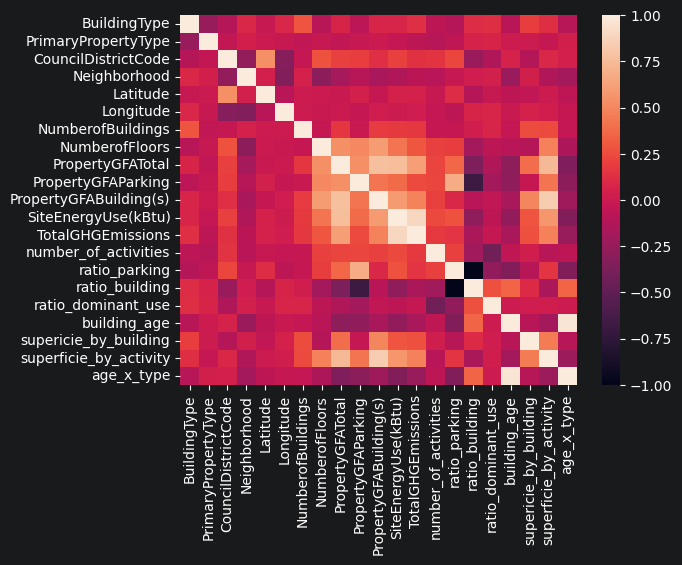

In [184]:
# On crée une copie pour ne pas altérer le dataframe original
data_copy = data.copy()

# On transforme chaque colonne textuelle en code numérique
for col in ['BuildingType', 'PrimaryPropertyType', 'Neighborhood']:
    data_copy[col] = pd.factorize(data_copy[col])[0]

# On calcule la corrélation
corr_matrix = data_copy.corr()
sns.heatmap(corr_matrix)

In [185]:
# Supression d'une age_x_type qui entre en correlation avec building_age
data.drop(columns='age_x_type', inplace=True)

## Outliers

In [186]:
# Analyse Z-Score des outlier
data['SiteEnergyUse(kBtu)'] = pd.to_numeric(data['SiteEnergyUse(kBtu)'], errors='coerce')
data['PropertyGFATotal'] = pd.to_numeric(data['PropertyGFATotal'], errors='coerce')

data['z_SiteEnergyUse(kBtu)'] = stats.zscore(data['SiteEnergyUse(kBtu)'], nan_policy='omit')
data['z_PropertyGFATotal'] = stats.zscore(data['PropertyGFATotal'], nan_policy='omit')

print(data[data['z_SiteEnergyUse(kBtu)'] > 3].shape)
print(data[data['z_PropertyGFATotal'] > 3].shape)

(6, 22)
(15, 22)


In [187]:
# Supression des colonnes qui n'apportent pas de plue-value
cols_to_remove = [
    'z_SiteEnergyUse(kBtu)',
    'z_PropertyGFATotal',
]

data.drop(columns=cols_to_remove, inplace=True)

In [188]:
# Analyse IQR des outliers

print('iqr energy')
iqr_energy = np.nanquantile(data['SiteEnergyUse(kBtu)'], q=[0.25, 0.75])
limite_basse_energy = iqr_energy[0] - 1.5*(iqr_energy[1] - iqr_energy[0])
limite_haute_energy = iqr_energy[1] + 1.5*(iqr_energy[1] - iqr_energy[0])
print(limite_basse_energy, limite_haute_energy)

print('iqr gfa')
iqr_gfa = np.quantile(data['PropertyGFATotal'], q=[0.25, 0.75])
limite_basse = iqr_gfa[0] - 1.5*(iqr_gfa[1] - iqr_gfa[0])
limite_haute = iqr_gfa[1] + 1.5*(iqr_gfa[1] - iqr_gfa[0])
print(limite_basse, limite_haute)

print(data[(data['SiteEnergyUse(kBtu)'] < limite_basse_energy) | (data['SiteEnergyUse(kBtu)']> limite_haute_energy)].shape)
print(data[(data['PropertyGFATotal'] < limite_basse) | (data['PropertyGFATotal']> limite_haute)].shape)


iqr energy
11.469686283207004 18.309424968417595
iqr gfa
8.36811279837044 13.458722495016445
(20, 20)
(32, 20)


In [189]:
import os

if not os.path.exists('./data/processed/'):
    os.mkdir('./data/processed/')

data.to_csv('./data/processed/data.csv', index=False)